In [16]:
!pip install wordcloud


In [2]:
# run 'pip install wordcloud'


import pandas as pd


df = pd.read_csv(r"c:\Users\reall\OneDrive\Desktop\CPC353\video_game_reviewsid.csv")

df.head()

,Game,review_text,sentiment,review_id
0,Elden Ring,I did not think I would ever experience such a...,Positive,1
1,Elden Ring,"Overall, it's the best game in the series and ...",Positive,2
2,Elden Ring,It is undoubtedly the most immersive fantasy w...,Positive,3
3,Elden Ring,First game in a long time where you get exactl...,Positive,4
4,Elden Ring,"\nGame is extremely good; however, wait for aw...",Negative,5


In [4]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    df['sentiment'] = df['sentiment'].str.strip().str.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation/numbers
    text = text.lower()
    tokens = [word for word in text.split() if word not in stop_words or word=='not']
    return ' '.join(tokens)
  

df['clean_review'] = df['review_text'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\reall\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
df.head()

,Game,review_text,sentiment,review_id,clean_review
0,Elden Ring,I did not think I would ever experience such a...,positive,1,not think would ever experience overwhelming f...
1,Elden Ring,"Overall, it's the best game in the series and ...",positive,2,overall best game series genre roleplaying games
2,Elden Ring,It is undoubtedly the most immersive fantasy w...,positive,3,undoubtedly immersive fantasy world ever found...
3,Elden Ring,First game in a long time where you get exactl...,positive,4,first game long time get exactly paid advertised
4,Elden Ring,"\nGame is extremely good; however, wait for aw...",negative,5,game extremely good however wait awhile planni...


In [8]:
from nltk import ngrams
from collections import Counter

def get_ngrams(text, n=2):
    tokens = text.split()
    return list(ngrams(tokens, n))

# Example for bigrams
all_bigrams = []
for text in df['clean_review']:
    all_bigrams.extend(get_ngrams(text, 2))

bigram_freq = Counter(all_bigrams).most_common(10)
print(bigram_freq)

[(('best', 'game'), 2), (('not', 'think'), 1), (('think', 'would'), 1), (('would', 'ever'), 1), (('ever', 'experience'), 1), (('experience', 'overwhelming'), 1), (('overwhelming', 'feeling'), 1), (('feeling', 'amazement'), 1), (('overall', 'best'), 1), (('game', 'series'), 1)]


In [10]:

def get_ngrams(text, n=2):
    tokens = text.split()
    return list(ngrams(tokens, n))

# Separate positive and negative reviews
positive_reviews = df[df['sentiment'] == 'positive']['clean_review']
negative_reviews = df[df['sentiment'] == 'negative']['clean_review']

# Collect positive bigrams
pos_bigrams = []
for text in positive_reviews:
    pos_bigrams.extend(get_ngrams(text, 2))

# Collect negative bigrams
neg_bigrams = []
for text in negative_reviews:
    neg_bigrams.extend(get_ngrams(text, 2))

# Count frequency
pos_bigram_freq = Counter(pos_bigrams).most_common(10)
neg_bigram_freq = Counter(neg_bigrams).most_common(10)

# Print top 10 most common
print("Top Positive Bigrams:")
for bg, count in pos_bigram_freq:
    print(f"{' '.join(bg)}: {count}")

print("\nTop Negative Bigrams:")
for bg, count in neg_bigram_freq:
    print(f"{' '.join(bg)}: {count}")

Top Positive Bigrams:
best game: 2
not think: 1
think would: 1
would ever: 1
ever experience: 1
experience overwhelming: 1
overwhelming feeling: 1
feeling amazement: 1
overall best: 1
game series: 1

Top Negative Bigrams:
game extremely: 1
extremely good: 1
good however: 1
however wait: 1
wait awhile: 1
awhile planning: 1
planning play: 1
play pc: 1
pc major: 1
major optimization: 1


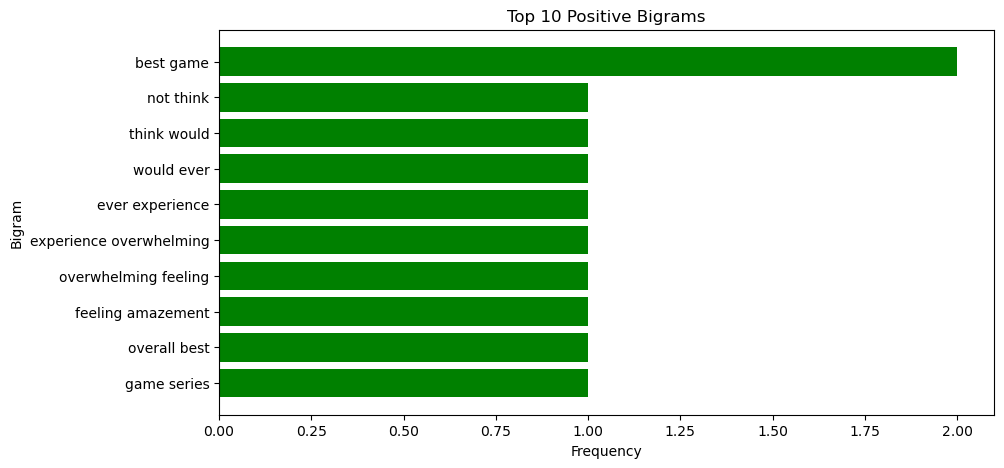

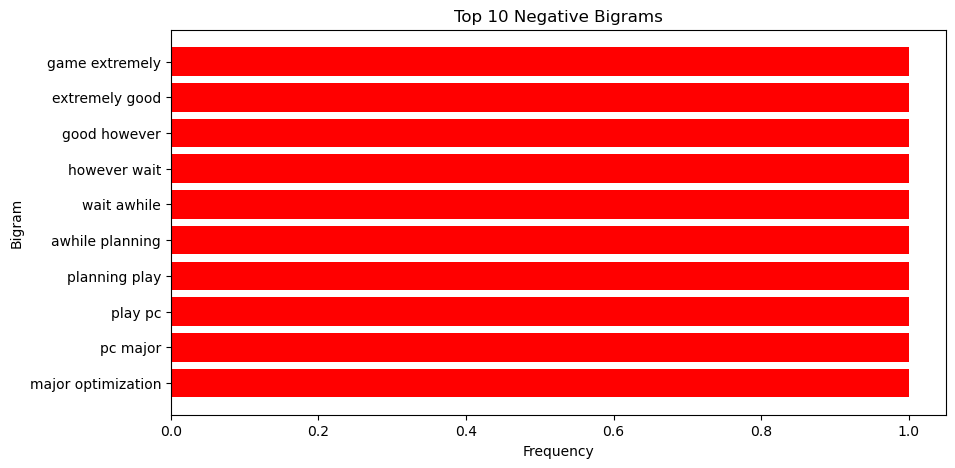

In [12]:
import matplotlib.pyplot as plt

positive_bigrams = [ ' '.join(b[0]) for b in pos_bigram_freq ]
positive_counts = [ b[1] for b in pos_bigram_freq ]

plt.figure(figsize=(10,5))
plt.barh(positive_bigrams, positive_counts, color='green')
plt.title("Top 10 Positive Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.gca().invert_yaxis()   # Show most frequent at top
plt.show()
#


negative_bigrams = [ ' '.join(b[0]) for b in neg_bigram_freq ]
negative_counts = [ b[1] for b in neg_bigram_freq ]

plt.figure(figsize=(10,5))
plt.barh(negative_bigrams, negative_counts, color='red')
plt.title("Top 10 Negative Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.gca().invert_yaxis()
plt.show()

In [14]:
def get_ngrams(text, n=1):
    tokens = text.split()
    return list(ngrams(tokens, n))


# Collect positive unigrams
pos_unigrams = []
for text in positive_reviews:
    pos_unigrams.extend(get_ngrams(text, 1))

# Collect negative bigrams
neg_unigrams = []
for text in negative_reviews:
    neg_unigrams.extend(get_ngrams(text, 1))

# Count frequency
pos_unigram_freq = Counter(pos_unigrams).most_common(10)
neg_unigram_freq = Counter(neg_unigrams).most_common(10)

# Print top 10 most common
print("Top Positive Unigrams:")
for bg, count in pos_unigram_freq:
    print(f"{' '.join(bg)}: {count}")

print("\nTop Negative Unigrams:")
for bg, count in neg_unigram_freq:
    print(f"{' '.join(bg)}: {count}")

Top Positive Unigrams:
game: 6
world: 4
ever: 2
best: 2
time: 2
building: 2
characters: 2
story: 2
not: 1
think: 1

Top Negative Unigrams:
game: 3
good: 3
issues: 2
not: 2
got: 2
pretty: 2
feels: 2
rpg: 2
world: 2
extremely: 1


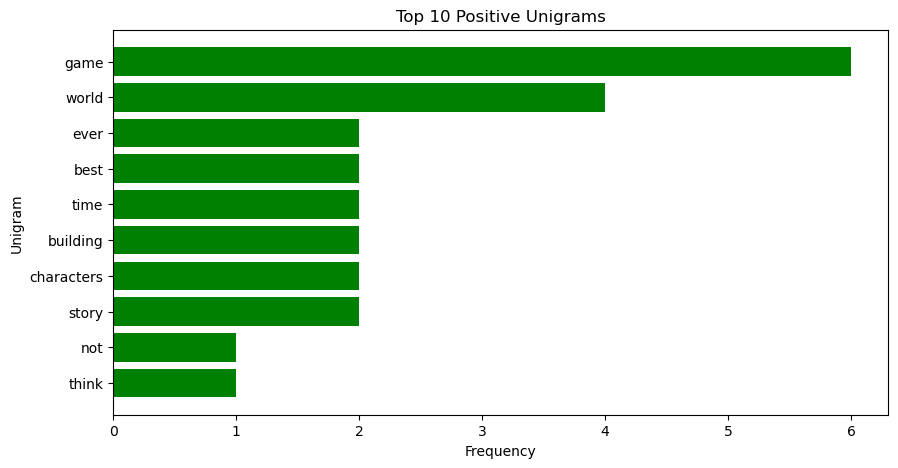

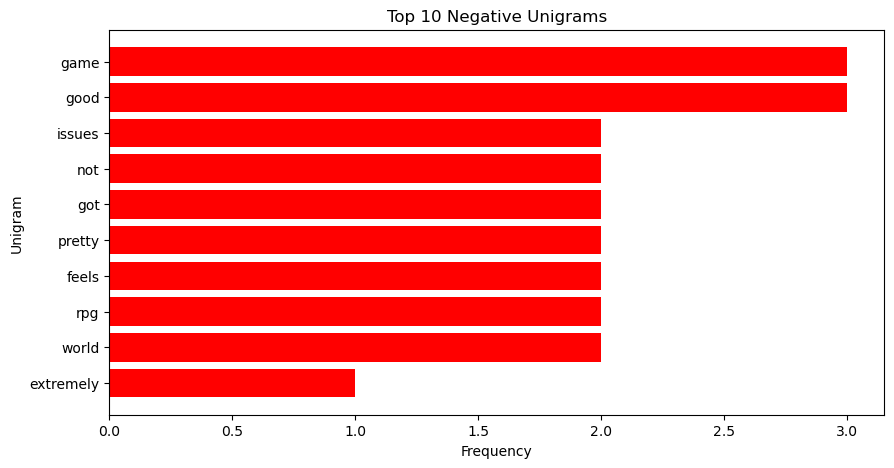

In [14]:
import matplotlib.pyplot as plt

positive_unigrams = [ ' '.join(b[0]) for b in pos_unigram_freq ]
positive_counts = [ b[1] for b in pos_unigram_freq ]

plt.figure(figsize=(10,5))
plt.barh(positive_unigrams, positive_counts, color='green')
plt.title("Top 10 Positive Unigrams")
plt.xlabel("Frequency")
plt.ylabel("Unigram")
plt.gca().invert_yaxis()   # Show most frequent at top
plt.show()
#


negative_unigrams = [ ' '.join(b[0]) for b in neg_unigram_freq ]
negative_counts = [ b[1] for b in neg_unigram_freq ]

plt.figure(figsize=(10,5))
plt.barh(negative_unigrams, negative_counts, color='red')
plt.title("Top 10 Negative Unigrams")
plt.xlabel("Frequency")
plt.ylabel("Unigram")
plt.gca().invert_yaxis()
plt.show()

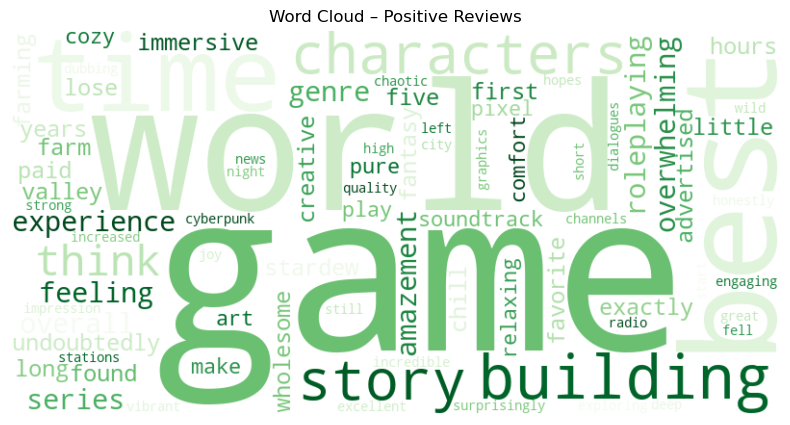

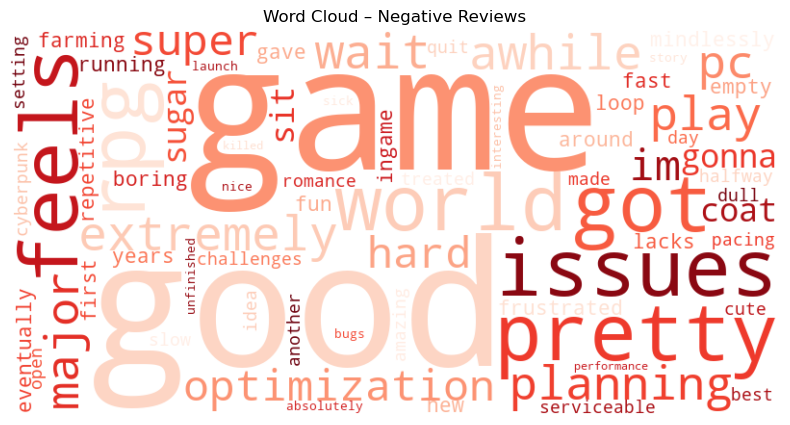

In [18]:
from wordcloud import WordCloud

positive_text = ' '.join(df[df['sentiment']=='positive']['clean_review'])
negative_text = ' '.join(df[df['sentiment']=='negative']['clean_review'])

# Positive reviews word cloud
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud – Positive Reviews")
plt.show()

# Negative reviews word cloud
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud – Negative Reviews")
plt.show()

In [20]:
def get_ngrams(text, n=3):
    tokens = text.split()
    return list(ngrams(tokens, n))


# Collect positive trigrams
pos_trigrams = []
for text in positive_reviews:
    pos_trigrams.extend(get_ngrams(text, 3))

# Collect negative trigrams
neg_trigrams = []
for text in negative_reviews:
    neg_trigrams.extend(get_ngrams(text, 3))

# Count frequency
pos_trigram_freq = Counter(pos_trigrams).most_common(10)
neg_trigram_freq = Counter(neg_trigrams).most_common(10)

# Print top 10 most common
print("Top Positive trigrams:")
for bg, count in pos_trigram_freq:
    print(f"{' '.join(bg)}: {count}")

print("\nTop Negative trigrams:")
for bg, count in neg_trigram_freq:
    print(f"{' '.join(bg)}: {count}")

Top Positive trigrams:
not think would: 1
think would ever: 1
would ever experience: 1
ever experience overwhelming: 1
experience overwhelming feeling: 1
overwhelming feeling amazement: 1
overall best game: 1
best game series: 1
game series genre: 1
series genre roleplaying: 1

Top Negative trigrams:
game extremely good: 1
extremely good however: 1
good however wait: 1
however wait awhile: 1
wait awhile planning: 1
awhile planning play: 1
planning play pc: 1
play pc major: 1
pc major optimization: 1
major optimization issues: 1


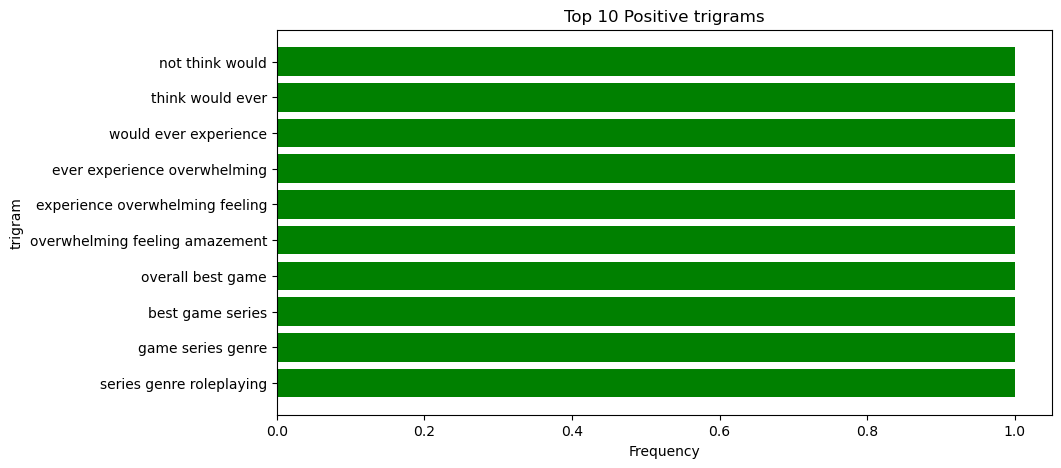

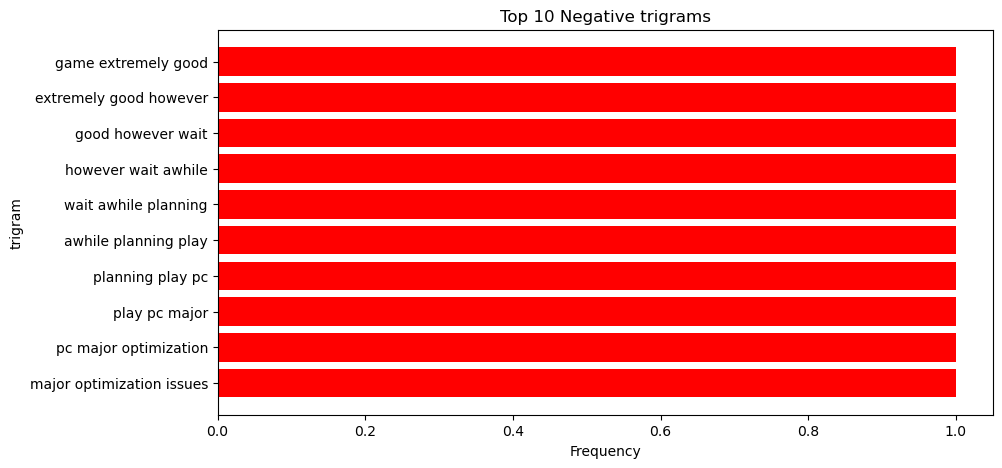

In [22]:
import matplotlib.pyplot as plt

positive_trigrams = [ ' '.join(b[0]) for b in pos_trigram_freq ]
positive_counts = [ b[1] for b in pos_trigram_freq ]

plt.figure(figsize=(10,5))
plt.barh(positive_trigrams, positive_counts, color='green')
plt.title("Top 10 Positive trigrams")
plt.xlabel("Frequency")
plt.ylabel("trigram")
plt.gca().invert_yaxis()   # Show most frequent at top
plt.show()
#


negative_trigrams = [ ' '.join(b[0]) for b in neg_trigram_freq ]
negative_counts = [ b[1] for b in neg_trigram_freq ]

plt.figure(figsize=(10,5))
plt.barh(negative_trigrams, negative_counts, color='red')
plt.title("Top 10 Negative trigrams")
plt.xlabel("Frequency")
plt.ylabel("trigram")
plt.gca().invert_yaxis()
plt.show()

## POS ANALYSIS

In [38]:
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\reall\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\reall\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [30]:
print('POS Tags Meanings\n')

pos_tag_meanings = {
    'NN': 'Noun, singular or mass',
    'NNS': 'Noun, plural',
    'JJ': 'Adjective',
    'JJR': 'Adjective, comparative',
    'JJS': 'Adjective, superlative',
    'RB': 'Adverb',
    'VBG': 'Verb, gerund/present participle',
    'VBD': 'Verb, past tense',
    'VB': 'Verb, base form',
    'VBP': 'Verb, non-3rd person singular present',
    'VBZ': 'Verb, 3rd person singular present',
    'IN': 'Preposition/subordinating conjunction'
}

for tag, meaning in pos_tag_meanings.items():
    print(f"{tag}: {meaning}")


def get_pos_counts(texts):
    all_pos = []
    for text in texts:
        tokens = nltk.word_tokenize(text)
        tags = nltk.pos_tag(tokens)
        all_pos.extend([tag for word, tag in tags])
    return Counter(all_pos)


positive_reviews = df[df['sentiment'] == 'positive']['clean_review']
negative_reviews = df[df['sentiment'] == 'negative']['clean_review']


pos_positive = get_pos_counts(positive_reviews)
pos_negative = get_pos_counts(negative_reviews)

print('\n')

print("Top POS in Positive Reviews:")
print(pos_positive.most_common(10))

print("\nTop POS in Negative Reviews:")
print(pos_negative.most_common(10))

POS Tags Meanings

NN: Noun, singular or mass
NNS: Noun, plural
JJ: Adjective
JJR: Adjective, comparative
JJS: Adjective, superlative
RB: Adverb
VBG: Verb, gerund/present participle
VBD: Verb, past tense
VB: Verb, base form
VBP: Verb, non-3rd person singular present
VBZ: Verb, 3rd person singular present
IN: Preposition/subordinating conjunction


Top POS in Positive Reviews:
[('NN', 39), ('JJ', 18), ('RB', 10), ('NNS', 10), ('VBG', 7), ('VBD', 4), ('VB', 3), ('VBP', 3), ('JJS', 2), ('MD', 1)]

Top POS in Negative Reviews:
[('NN', 23), ('JJ', 18), ('RB', 14), ('NNS', 7), ('VBD', 6), ('VBG', 5), ('VB', 4), ('VBZ', 2), ('VBP', 1), ('IN', 1)]


In [32]:
def extract_words_by_pos(texts, pos_tag):
    words = []
    for text in texts:
        tokens = nltk.word_tokenize(text)
        tags = nltk.pos_tag(tokens)
        words.extend([word for word, tag in tags if tag == pos_tag])
    return Counter(words).most_common(10)

# Example: Top adjectives and verbs
top_adj_pos = extract_words_by_pos(positive_reviews, 'JJ')
top_adj_neg = extract_words_by_pos(negative_reviews, 'JJ')

print("Top Adjectives in Positive Reviews:", top_adj_pos)
print("Top Adjectives in Negative Reviews:", top_adj_neg)


Top Adjectives in Positive Reviews: [('feeling', 1), ('overall', 1), ('immersive', 1), ('long', 1), ('advertised', 1), ('favorite', 1), ('creative', 1), ('lose', 1), ('little', 1), ('pixel', 1)]
Top Adjectives in Negative Reviews: [('good', 3), ('major', 1), ('super', 1), ('repetitive', 1), ('boring', 1), ('empty', 1), ('new', 1), ('cute', 1), ('dull', 1), ('serviceable', 1)]


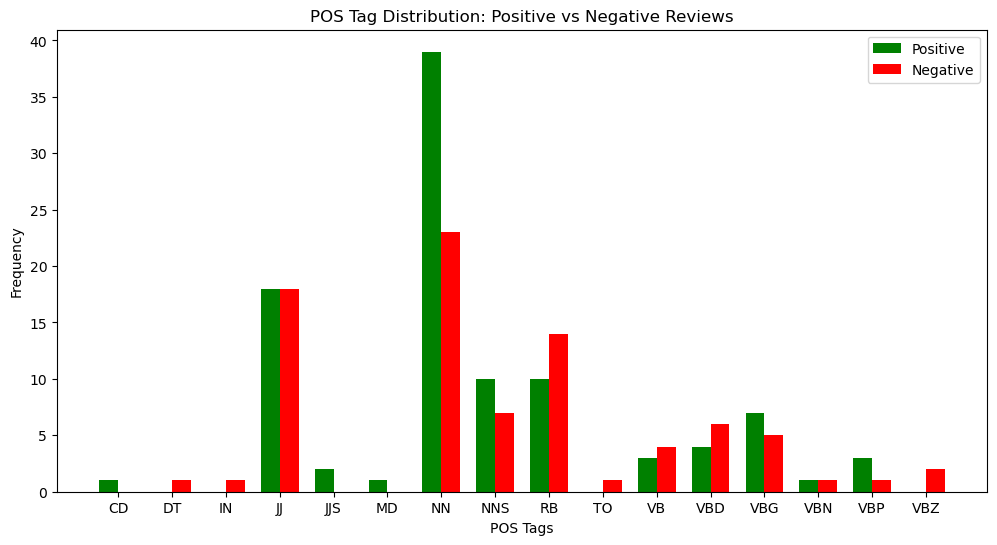

In [34]:
import numpy as np


tags = list(set(list(pos_positive.keys()) + list(pos_negative.keys())))
tags.sort()

positive_counts = [pos_positive.get(tag, 0) for tag in tags]
negative_counts = [pos_negative.get(tag, 0) for tag in tags]

x = np.arange(len(tags))
width = 0.35

plt.figure(figsize=(12,6))
plt.bar(x - width/2, positive_counts, width, label='Positive', color='green')
plt.bar(x + width/2, negative_counts, width, label='Negative', color='red')

plt.xticks(x, tags)
plt.xlabel('POS Tags')
plt.ylabel('Frequency')
plt.title('POS Tag Distribution: Positive vs Negative Reviews')
plt.legend()
plt.show()
